<a href="https://colab.research.google.com/github/ZeeMurphy/Data_205_Capstone_Project/blob/main/analysis/notebooks/Capstone_205_Cognitive_Decline_Analysis_April22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Cognitive Decline Risk Factors in U.S. Older Adults**
## Data Ingestion and Exploratory Data Analysis (EDA)

**Datasets:**
1. **CDC BRFSS — Alzheimer's Disease and Healthy Aging Data (2015–2022)**
   - Loaded live via CDC SODA2 API — no file upload or API key needed
   - Source: data.cdc.gov/Healthy-Aging/Alzheimer-s-Disease-and-Healthy-Aging-Data/hfr9-rurv

2. **U.S. Census Bureau — American Community Survey (ACS) 2022**
   - DP03_0062E — Median household income in dollars
   - DP02_0068PE — % of adults 25+ with bachelor's degree or higher
   - Data hardcoded from official ACS 2022 5-year estimates
   - Source: census.gov/data/developers/data-sets/acs-5year.html

**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn · Scikit-learn · Plotly

---

The goal of this project is to explore which health, behavioral, and
socioeconomic factors are most strongly linked to cognitive decline
(memory loss) among older adults across U.S. states, and to provide
insights for policymakers to identify high-risk populations and guide
interventions. This notebook covers data loading, cleaning, exploratory
data analysis, correlation analysis, regression modeling, and
interactive mapping.

---

## Research Questions

| RQ | Question |
|---|---|
| RQ1 | Which states have the highest cognitive decline rates? |
| RQ2 | Do cognitive decline rates differ between the 50–64 and 65+ age groups? |
| RQ3 | Are early-stage memory complaints linked to severe cognitive decline? |
| RQ4 | Is there a relationship between depression and cognitive decline? |
| RQ5 | Does physical inactivity correlate with cognitive decline? |
| RQ6 | How does poor self-reported health relate to cognitive decline? |
| RQ7 | Is cognitive decline associated with disability rates? |
| RQ8 | Does the smoking rate among older adults correlate with cognitive decline? |
| RQ9 | Does the binge drinking rate correlate with cognitive decline? |
| RQ10 | Does median household income relate to cognitive decline across states? |
| RQ11 | Does higher educational attainment reduce cognitive decline? |
| RQ12 | Which combination of variables best predicts cognitive decline? |

## Part 1: Load and Clean the Data

**Data Source:** CDC BRFSS Alzheimer's Disease and Healthy Aging Data (2015–2022)  
Loaded live using the CDC Socrata SODA2 API — no file upload or API key needed.

A few things to know about this API:
- It takes about 30–60 seconds to load since it downloads ~140MB from the CDC website
- The API returns all column names in lowercase, so we rename them to match the original CDC CSV format
- We lock the data to 2015–2022 using a year filter so results stay consistent even if CDC adds new years later
- The default API limit is 1,000 rows — we override this with `$limit=300000` to get all 284,142 rows    
The dataset has 284,142 rows and 31 columns. Each row represents one survey answer for one question, in one location, in one year, for one age subgroup. This is called long format, I'll reshape it later.(In long format, each row contains only one single measurement. So instead of having one row per state with all questions as columns, each question gets its own separate row. For example, if Alabama reported 10 different survey questions in 2019, that would be 10 separate rows in the dataset rather than one row with 10 columns. We will reshape it into wide format later so each state-year becomes one row with all questions as columns, which is what we need for correlation analysis.)

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Load CDC dataset live from CDC website (SODA2 API, no key needed)
# Source: data.cdc.gov/Healthy-Aging/Alzheimer-s-Disease-and-Healthy-Aging-Data/hfr9-rurv
CDC_URL = "https://data.cdc.gov/resource/hfr9-rurv.csv?$limit=300000"
df = pd.read_csv(CDC_URL, engine="python", on_bad_lines="skip")

# The API returns lowercase column names but our code expects mixed case
# This line renames them to match the original CSV format exactly
df.columns = [
    'RowId', 'YearStart', 'YearEnd', 'LocationAbbr', 'LocationDesc',
    'Datasource', 'Class', 'Topic', 'Question', 'Data_Value_Unit',
    'DataValueTypeID', 'Data_Value_Type', 'Data_Value', 'Data_Value_Alt',
    'Data_Value_Footnote_Symbol', 'Data_Value_Footnote',
    'Low_Confidence_Limit', 'High_Confidence_Limit',
    'StratificationCategory1', 'Stratification1',
    'StratificationCategory2', 'Stratification2', 'Geolocation',
    'ClassID', 'TopicID', 'QuestionID', 'LocationID',
    'StratificationCategoryID1', 'StratificationID1',
    'StratificationCategoryID2', 'StratificationID2'
]

# Convert YearStart to numeric — API returns it as text
df["YearStart"] = pd.to_numeric(df["YearStart"], errors="coerce")

# Lock to 2015-2022 so results don't change if CDC adds new years later
df = df[df["YearStart"].between(2015, 2022)]

print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df.head()

Rows: 284,142 | Columns: 31


,RowId,YearStart,YearEnd,LocationAbbr,LocationDesc,Datasource,Class,Topic,Question,Data_Value_Unit,...,Stratification2,Geolocation,ClassID,TopicID,QuestionID,LocationID,StratificationCategoryID1,StratificationID1,StratificationCategoryID2,StratificationID2
0,BRFSS~2015~2015~66~Q35~TOC03~AGE~SEX,2015,2015,GU,Guam,BRFSS,Overall Health,Recent activity limitations in past month,Mean number of days with activity limitations ...,Number,...,Female,POINT (144.793731 13.444304),C01,TOC03,Q35,66,AGE,AGE_OVERALL,SEX,FEMALE
1,BRFSS~2015~2015~25~Q27~TMC03~AGE~SEX,2015,2015,MA,Massachusetts,BRFSS,Mental Health,Lifetime diagnosis of depression,Percentage of older adults with a lifetime dia...,%,...,Male,POINT (-72.08269067499964 42.27687047000046),C05,TMC03,Q27,25,AGE,65PLUS,SEX,MALE
2,BRFSS~2015~2015~9002~Q43~TOC11~AGE~SEX,2015,2015,MDW,Midwest,BRFSS,Overall Health,Arthritis among older adults,Percentage of older adults ever told they have...,%,...,Male,NaN,C01,TOC11,Q43,9002,AGE,5064,SEX,MALE
3,BRFSS~2015~2015~27~Q03~TMC01~AGE~SEX,2015,2015,MN,Minnesota,BRFSS,Mental Health,Frequent mental distress,Percentage of older adults who are experiencin...,%,...,Male,POINT (-94.79420050299967 46.35564873600049),C05,TMC01,Q03,27,AGE,AGE_OVERALL,SEX,MALE
4,BRFSS~2015~2015~29~Q43~TOC11~AGE~OVERALL,2015,2015,MO,Missouri,BRFSS,Overall Health,Arthritis among older adults,Percentage of older adults ever told they have...,%,...,NaN,POINT (-92.56630005299968 38.635790776000476),C01,TOC11,Q43,29,AGE,AGE_OVERALL,OVERALL,OVERALL


In [78]:
# Check data types and see which columns have missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284142 entries, 0 to 284141
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   RowId                       284142 non-null  object 
 1   YearStart                   284142 non-null  int64  
 2   YearEnd                     284142 non-null  int64  
 3   LocationAbbr                284142 non-null  object 
 4   LocationDesc                284142 non-null  object 
 5   Datasource                  284142 non-null  object 
 6   Class                       284142 non-null  object 
 7   Topic                       284142 non-null  object 
 8   Question                    284142 non-null  object 
 9   Data_Value_Unit             284142 non-null  object 
 10  DataValueTypeID             284142 non-null  object 
 11  Data_Value_Type             284142 non-null  object 
 12  Data_Value                  192808 non-null  float64
 13  Data_Value_Alt

In [79]:
# --- Data Cleaning ---
# Step 1: Make a copy so I don't change the original
df_clean = df.copy()

# Step 2: Replace different versions of missing values with one standard (pd.NA)
df_clean = df_clean.replace(["", " ", "NA", "N/A"], pd.NA)

# Step 3: Convert Data_Value and YearStart to numbers
# errors='coerce' turns anything that can't be converted into NaN instead of crashing
df_clean["Data_Value"] = pd.to_numeric(df_clean["Data_Value"], errors="coerce")
df_clean["YearStart"]  = pd.to_numeric(df_clean["YearStart"],  errors="coerce")

# Step 4: Drop rows missing the value or the year — they can't be used in any analysis
before = len(df_clean)
df_clean = df_clean.dropna(subset=["Data_Value", "YearStart"]).copy()

print(f"Rows before cleaning: {before:,}")
print(f"Rows after cleaning:  {len(df_clean):,}")
print(f"Rows dropped:         {before - len(df_clean):,}")

Rows before cleaning: 284,142
Rows after cleaning:  192,808
Rows dropped:         91,334


In [80]:
# Quick look at what's in the key columns
print("Unique locations:", df_clean['LocationAbbr'].nunique())
print(sorted(df_clean['LocationAbbr'].unique()))
print("\nAge group options:", df_clean['Stratification1'].unique())
print("\nHealth topic classes:", sorted(df_clean['Class'].unique()))

Unique locations: 59
['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'GU', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'MDW', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NRE', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'PR', 'RI', 'SC', 'SD', 'SOU', 'TN', 'TX', 'US', 'UT', 'VA', 'VI', 'VT', 'WA', 'WEST', 'WI', 'WV', 'WY']

Age group options: ['Overall' '65 years or older' '50-64 years']

Health topic classes: ['Caregiving', 'Cognitive Decline', 'Mental Health', 'Nutrition/Physical Activity/Obesity', 'Overall Health', 'Screenings and Vaccines', 'Smoking and Alcohol Use']


The dataset includes 59 locations — not just the 50 states. It also includes U.S. territories like Puerto Rico and Guam, plus regional averages for the Midwest, South, Northeast, and West. I'll filter these out and keep only the 50 states + D.C. for my state-level analysis.

Each question also appears three times per state-year: once for the full 'Overall' group, once for ages 50–64, and once for ages 65+. I'll use 'Overall' for most analysis to avoid counting the same state three times.

## Part 1b: All Available Questions in the Dataset

Here is a full inventory
of every survey question available in the CDC BRFSS dataset,
organized by health topic class.

In [81]:
# ── All questions available in the dataset by topic class ────
print("All questions by health topic class:")
print("=" * 65)

for cls in sorted(df_clean['Class'].unique()):
    questions = df_clean[df_clean['Class'] == cls]['Question'].unique()
    print(f"\n📋 {cls.upper()} ({len(questions)} questions)")
    print("-" * 65)
    for i, q in enumerate(sorted(questions), 1):
        print(f"  {i}. {q}")

All questions by health topic class:

📋 CAREGIVING (5 questions)
-----------------------------------------------------------------
  1. Average of 20 or more hours of care per week provided to a friend or family member
  2. Percentage of older adults currently not providing care who expect to provide care for someone with health problems in the next two years
  3. Percentage of older adults who provided care for a friend or family member within the past month
  4. Percentage of older adults who provided care for someone with dementia or other cognitive impairment within the past month
  5. Percentage of older adults who provided care to a friend or family member for six months or more

📋 COGNITIVE DECLINE (4 questions)
-----------------------------------------------------------------
  1. Percentage of older adults who reported subjective cognitive decline or memory loss that interferes with their ability to engage in social activities or household chores
  2. Percentage of older adult

## Part 2: Check Data Coverage by Year

Before building my analysis dataset, I want to check how many states reported cognitive decline data each year. The cognitive decline module in BRFSS is optional — states choose whether to include it. This means some years have much less data than others, which is an important limitation to keep in mind.

In [82]:
cognitive_questions = [
    "Percentage of older adults who reported subjective cognitive decline or memory loss that interferes with their ability to engage in social activities or household chores",
    "Percentage of older adults who reported subjective cognitive decline or memory loss that is happening more often or is getting worse in the preceding 12 months",
    "Percentage of older adults who reported that as a result of subjective cognitive decline or memory loss that they need assistance with day-to-day activities",
    "Percentage of older adults with subjective cognitive decline or memory loss who reported talking with a health care professional about it"
]

# Non-state locations to exclude
exclude = ["US", "NRE", "MDW", "SOU", "WEST"]

coverage = df_clean[
    (df_clean["Question"].isin(cognitive_questions)) &
    (~df_clean["LocationAbbr"].isin(exclude)) &
    (df_clean["Stratification1"] == "Overall")
].groupby(["Question", "YearStart"])["LocationAbbr"].nunique().unstack(fill_value=0)

coverage.index = ["Interferes with activities", "Getting worse", "Needs assistance", "Talked to doctor"]
print("States reporting each cognitive decline question per year:")
print(coverage.to_string())

States reporting each cognitive decline question per year:
YearStart                   2015  2016  2017  2018  2019  2020  2021  2022
Interferes with activities    35    21    10     6    49    23    15    18
Getting worse                 35    21    10     6    49    23    15    18
Needs assistance              35    21    10     6    49    23    15    18
Talked to doctor              35    21    10     6    49    23    15    18


Coverage dropped sharply in 2017–2018 (only 10 and 6 states), then recovered in 2019 (49 states). This means year-to-year comparisons need to be interpreted carefully, the national average in 2018 is based on only 6 states, which may not represent the whole country.

## Part 3: Define Variables and Build Analysis Dataset

I'm selecting one cognitive decline question as my main outcome (target), plus eight health and behavioral variables as predictors. Then I'll filter and reshape the data into wide format, one row per state per year, with each variable as its own column.

In [83]:
# Main outcome variable (target)
target = "Percentage of older adults who reported subjective cognitive decline or memory loss that interferes with their ability to engage in social activities or household chores"

# The other three cognitive decline questions (used in RQ9)
q_worse      = "Percentage of older adults who reported subjective cognitive decline or memory loss that is happening more often or is getting worse in the preceding 12 months"
q_assistance = "Percentage of older adults who reported that as a result of subjective cognitive decline or memory loss that they need assistance with day-to-day activities"
q_talked     = "Percentage of older adults with subjective cognitive decline or memory loss who reported talking with a health care professional about it"

# Eight risk factor variables (predictors for RQ2–RQ5)
risk_factors = [
    "Percentage of older adults with a lifetime diagnosis of depression",
    "Percentage of older adults who are experiencing frequent mental distress",
    "Percentage of older adults who have not had any leisure time physical activity in the past month",
    'Percentage of older adults who self-reported that their health is "fair" or "poor"',
    "Physically unhealthy days (mean number of days in past month)",
    "Percentage of older adults who report having a disability (includes limitations related to sensory or mobility impairments or a physical, mental, or emotional condition)",
    "Percentage of older adults who have smoked at least 100 cigarettes in their entire life and still smoke every day or some days",
    "Percentage of older adults who reported binge drinking within the past 30 days"
    ]

# Short names for chart labels
short_names = {
    target: "Cognitive Decline (%)",
    q_worse: "Getting Worse",
    q_assistance: "Needs Assistance",
    q_talked: "Talked to Doctor",
    'Percentage of older adults who self-reported that their health is "fair" or "poor"': "Poor Health",
    "Percentage of older adults who have not had any leisure time physical activity in the past month": "Physical Inactivity",
    "Percentage of older adults who report having a disability (includes limitations related to sensory or mobility impairments or a physical, mental, or emotional condition)": "Disability",
    "Percentage of older adults who are experiencing frequent mental distress": "Mental Distress",
    "Physically unhealthy days (mean number of days in past month)": "Unhealthy Days",
    "Percentage of older adults with a lifetime diagnosis of depression": "Depression",
    "Percentage of older adults who have smoked at least 100 cigarettes in their entire life and still smoke every day or some days": "Smoking",
    "Percentage of older adults who reported binge drinking within the past 30 days": "Binge Drinking"
}

# U.S. states + DC only
us_states = [
    'AL','AK','AZ','AR','CA','CO','CT','DE','FL','GA','HI','ID','IL','IN',
    'IA','KS','KY','LA','ME','MD','MA','MI','MN','MS','MO','MT','NE','NV',
    'NH','NJ','NM','NY','NC','ND','OH','OK','OR','PA','RI','SC','SD','TN',
    'TX','UT','VT','VA','WA','WV','WI','WY','DC'
]

print("Variables set up.")

Variables set up.


The dataset includes 59 locations, not just the 50 states. It also
contains U.S. territories (Puerto Rico, Guam, Virgin Islands) and
regional rollups (Midwest, Northeast, South, West) and a national
total. We exclude all of these for three reasons:

1. Territories are not U.S. states and have very different healthcare
   systems and demographics, so I exclude them from my analysis in this document.

2. Regional rollups (Midwest, South, etc.) are aggregates of states
   already in the data, keeping them would mean double-counting the
   same observations.

3. The national total (US) is a summary of all states combined, not
   an individual location.

The final filter keeps only the 50 states + DC, making each row in
the analysis represent one distinct geographic unit.

In [84]:
# Filter to only the questions I need, Overall age group, and U.S. states only
# Note: filtering to states only is important — without this, Puerto Rico and
# regional averages like 'South' would appear as rows in my charts
all_questions = [target] + risk_factors

df_filtered = df_clean[
    (df_clean["Question"].isin(all_questions)) &
    (df_clean["Stratification1"] == "Overall") &
    (df_clean["LocationAbbr"].isin(us_states))
].copy()

# Reshape from long to wide format
# Each row = one state + one year, each question becomes its own column
# aggfunc='mean' averages across the sex/race breakdowns that exist within 'Overall'
pivot = df_filtered.pivot_table(
    index=["LocationAbbr", "LocationDesc", "YearStart"],
    columns="Question",
    values="Data_Value",
    aggfunc="mean"
).reset_index()
pivot.columns.name = None

print(f"Analysis dataset shape: {pivot.shape}")
print(f"This means {pivot.shape[0]} state-year combinations across {pivot['LocationAbbr'].nunique()} states")
pivot.head(3)

Analysis dataset shape: (406, 12)
This means 406 state-year combinations across 51 states


,LocationAbbr,LocationDesc,YearStart,Percentage of older adults who are experiencing frequent mental distress,Percentage of older adults who have not had any leisure time physical activity in the past month,Percentage of older adults who have smoked at least 100 cigarettes in their entire life and still smoke every day or some days,"Percentage of older adults who report having a disability (includes limitations related to sensory or mobility impairments or a physical, mental, or emotional condition)",Percentage of older adults who reported binge drinking within the past 30 days,Percentage of older adults who reported subjective cognitive decline or memory loss that interferes with their ability to engage in social activities or household chores,"Percentage of older adults who self-reported that their health is ""fair"" or ""poor""",Percentage of older adults with a lifetime diagnosis of depression,Physically unhealthy days (mean number of days in past month)
0,AK,Alaska,2015,9.24,31.04,19.44,NaN,13.60,NaN,20.98,16.68,4.84
1,AK,Alaska,2016,9.56,24.60,17.76,30.24,13.18,29.475,22.20,12.98,5.74
2,AK,Alaska,2017,7.10,26.36,20.86,28.66,13.46,NaN,21.44,15.84,5.18


## Part 4: Missing Value Analysis

Now I'll check how much data is missing in the pivot table. A quick note on why the numbers might look small: the missing percentages are calculated out of **406 state-year rows**, not the original 284,142 rows. After pivoting, each row represents one state in one year, so there are only about 406 possible combinations (51 states × 8 years).

The cognitive decline variable has the most missing data because it comes from an **optional** BRFSS module, states choose whether to run it each year. The other variables (depression, physical inactivity, poor health) come from **core** modules that nearly every state runs every year, which is why they have almost no missing data.

In [85]:
# Count missing values per column
missing = pd.DataFrame({
    'Missing Count': pivot.isna().sum(),
    'Missing %': (pivot.isna().mean() * 100).round(1)
})
missing.index = [short_names.get(c, c) for c in missing.index]
print("Missing values (out of", len(pivot), "state-year rows):")
missing[missing['Missing Count'] > 0]

Missing values (out of 406 state-year rows):


,Missing Count,Missing %
Disability,51,12.6
Cognitive Decline (%),233,57.4


In [86]:
# Drop rows where the main cognitive decline variable is missing
# I keep rows where only a risk factor is missing — those can still be used in some charts
before = len(pivot)
pivot_clean = pivot.dropna(subset=[target]).copy()

print(f"Rows before: {before}  |  Rows after: {len(pivot_clean)}  |  Dropped: {before - len(pivot_clean)}")
print(f"States with cognitive decline data: {pivot_clean['LocationDesc'].nunique()}")
print(f"Years covered: {sorted(pivot_clean['YearStart'].unique())}")

Rows before: 406  |  Rows after: 173  |  Dropped: 233
States with cognitive decline data: 51
Years covered: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]


In [87]:
# ── Coverage check for all selected variables ────────────────
# How many state-year observations does each variable have?
# This helps understand the reliability of each correlation.

all_vars = [target] + risk_factors

coverage_check = pd.DataFrame({
    "Variable": [short_names.get(v, v) for v in all_vars],
    "Observations": [pivot_clean[v].notna().sum() for v in all_vars],
    "Missing": [pivot_clean[v].isna().sum() for v in all_vars],
    "Missing %": [(pivot_clean[v].isna().mean() * 100).round(1) for v in all_vars],
    "States with data": [
        pivot_clean.dropna(subset=[v])["LocationAbbr"].nunique()
        for v in all_vars
    ]
})

coverage_check = coverage_check.sort_values("Missing %", ascending=False)
print(f"Total state-year rows: {len(pivot_clean)}")
print()
display(coverage_check)

Total state-year rows: 173



,Variable,Observations,Missing,Missing %,States with data
6,Disability,139,34,19.7,51
0,Cognitive Decline (%),173,0,0.0,51
1,Depression,173,0,0.0,51
3,Physical Inactivity,173,0,0.0,51
2,Mental Distress,173,0,0.0,51
4,Poor Health,173,0,0.0,51
5,Unhealthy Days,173,0,0.0,51
7,Smoking,173,0,0.0,51
8,Binge Drinking,173,0,0.0,51


## Part 5: Descriptive Statistics

Basic summary statistics for all the variables I'll be analyzing.

In [88]:
# Summary statistics — only for the analysis variables, not YearStart or location names
analysis_cols = [c for c in [target] + risk_factors if c in pivot_clean.columns]

stats = pivot_clean[analysis_cols].describe().T.round(2)
stats.index = [short_names.get(c, c) for c in stats.index]
stats

,count,mean,std,min,25%,50%,75%,max
Cognitive Decline (%),173.0,36.69,6.87,22.42,31.53,35.92,41.13,53.10
Depression,173.0,18.16,3.33,12.24,15.77,18.05,20.42,28.44
Mental Distress,173.0,11.05,2.06,6.15,9.53,10.98,12.58,16.92
Physical Inactivity,173.0,30.31,5.14,21.28,26.42,30.14,33.37,45.74
Poor Health,173.0,25.44,4.78,13.68,22.20,25.69,27.88,38.48
Unhealthy Days,173.0,5.30,0.87,3.23,4.70,5.32,5.82,7.60
Disability,139.0,37.60,5.44,27.47,34.15,36.90,40.25,53.52
Smoking,173.0,15.05,3.46,6.26,12.47,14.61,17.85,22.10
Binge Drinking,173.0,9.50,1.77,4.40,8.40,9.50,10.48,14.66


## Part 6: RQ1 — Which States Have the Highest Cognitive Decline?

I'm calculating each state's average cognitive decline rate across all the years it reported. States reported in different years, so the averages are based on different numbers of observations,  but each state's average only uses years where it actually participated, so no data is being made up or filled in for missing years.

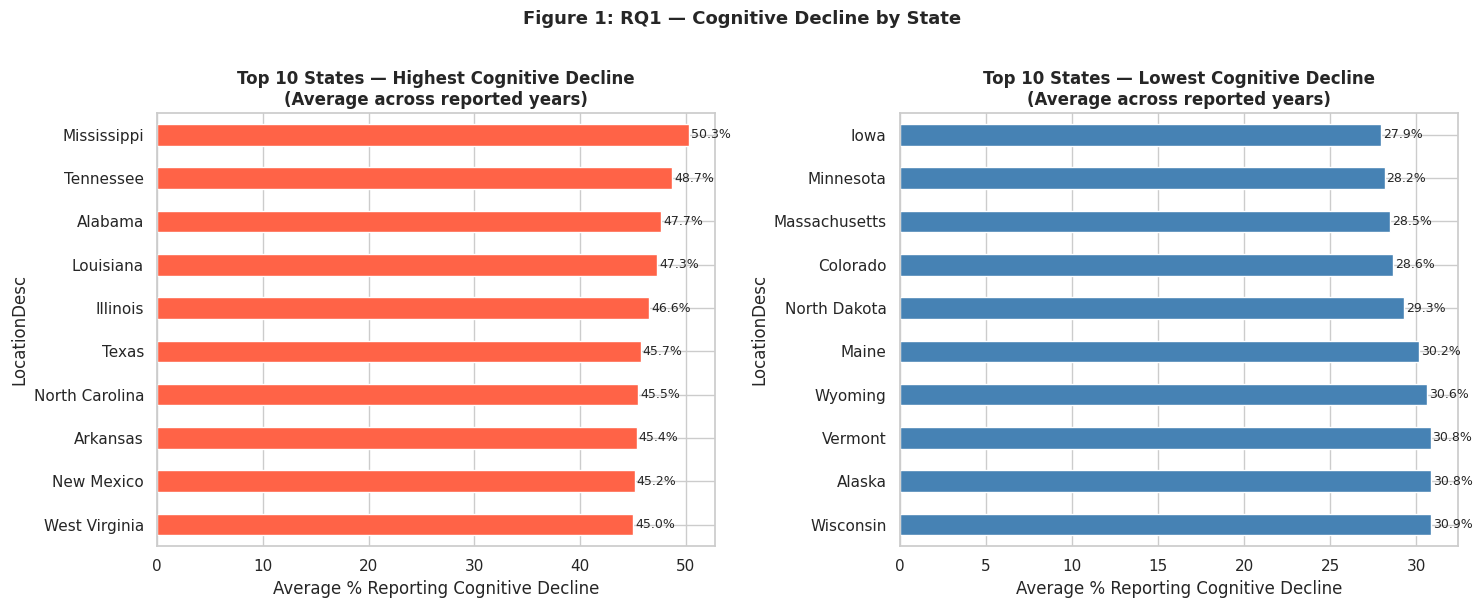

In [121]:
# Average cognitive decline per state (only years with actual data)
state_avg = pivot_clean.groupby("LocationDesc")[target].mean().sort_values(ascending=False)

top10    = state_avg.head(10).sort_values()
bottom10 = state_avg.tail(10).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top10.plot(kind='barh', ax=axes[0], color='tomato', edgecolor='white')
axes[0].set_title('Top 10 States — Highest Cognitive Decline\n(Average across reported years)', fontweight='bold')
axes[0].set_xlabel('Average % Reporting Cognitive Decline')
for i, v in enumerate(top10.values):
    axes[0].text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=9)

bottom10.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Top 10 States — Lowest Cognitive Decline\n(Average across reported years)', fontweight='bold')
axes[1].set_xlabel('Average % Reporting Cognitive Decline')
for i, v in enumerate(bottom10.values):
    axes[1].text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=9)

plt.suptitle('Figure 1: RQ1 — Cognitive Decline by State', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [90]:
# States that reported at least once
states_with_data = pivot_clean["LocationAbbr"].unique()

# All 51 states + DC we filtered to
all_states = us_states

# States that NEVER reported cognitive decline
states_no_data = [s for s in all_states if s not in states_with_data]

print(f"States with NO cognitive decline data at all: {len(states_no_data)}")
for s in sorted(states_no_data):
    print(f"  {s}")

States with NO cognitive decline data at all: 0


In [91]:
years_per_state = (
    pivot_clean.groupby(["LocationAbbr", "LocationDesc"])[target]
    .count()
    .reset_index()
    .rename(columns={target: "Years_Reported"})
    .sort_values("Years_Reported")
)

print("Years of cognitive decline data per state:")
print(years_per_state.to_string(index=False))

Years of cognitive decline data per state:
LocationAbbr         LocationDesc  Years_Reported
          MT              Montana               1
          MA        Massachusetts               1
          AL              Alabama               2
          MO             Missouri               2
          KS               Kansas               2
          LA            Louisiana               2
          NE             Nebraska               2
          ND         North Dakota               2
          MN            Minnesota               2
          WV        West Virginia               2
          SD         South Dakota               2
          NM           New Mexico               2
          CT          Connecticut               3
          AK               Alaska               3
          AR             Arkansas               3
          CO             Colorado               3
          NH        New Hampshire               3
          NC       North Carolina               3
       

### Data Coverage Analysis: Years of Cognitive Decline Data per State

Not all states reported cognitive decline data every year since the
BRFSS cognitive decline module is optional. Coverage varies widely
across states, which affects the reliability of state averages.

**Coverage summary:**
- Only **Oregon** reported data all 8 years, the only state with
  complete coverage
- **Michigan and New York** reported 7 years,  nearly complete
- **Montana and Massachusetts** reported only 1 year — their averages
  are based on a single observation and should be interpreted with
  caution. Notably, Massachusetts appears in the top 10 lowest states
  at 28.5% but this is based on just one year of data
- The most common coverage is **3 years** (19 states including Texas,
  Florida, Iowa, and Colorado)
- **12 states** reported only 1-2 years, making their averages the
  least stable in the dataset

**What this means for the analysis:**
State averages in this project are means across however many years
each state reported, not means across all 8 years. This is an
unbalanced panel, which is standard for optional BRFSS modules.
States with more years of data have more reliable averages. Results
for states with only 1-2 years should be interpreted carefully and
treated as less stable estimates. Despite this limitation, all 50
states and DC contributed at least one observation, and the overall
geographic patternsm particularly Southern states clustering at
the high end, are consistent across multiple states with varying
coverage levels, which supports the reliability of the regional
findings.

## Part 7: RQ2— Does Age Group Matter?

Here I compare cognitive decline rates between the 50–64 age group and the 65+ age group. The BRFSS data already has this broken down by age, so I can use that directly.

In [92]:
# Build age group comparison using the BRFSS stratification column
age_df = df_clean[
    (df_clean["Question"] == target) &
    (df_clean["LocationAbbr"].isin(us_states)) &
    (df_clean["Stratification1"].isin(["50-64 years", "65 years or older"]))
].copy()

age_pivot = age_df.pivot_table(
    index=["LocationAbbr", "LocationDesc", "YearStart"],
    columns="Stratification1",
    values="Data_Value",
    aggfunc="mean"
).reset_index()
age_pivot.columns.name = None

# Compare average rates by age group
avg_by_group = age_pivot[["50-64 years", "65 years or older"]].mean()
print("Average cognitive decline rate by age group:")
print(avg_by_group.round(2))

r_age = age_pivot["50-64 years"].corr(age_pivot["65 years or older"])
print(f"\nCorrelation between age groups: r = {r_age:.2f}")

Average cognitive decline rate by age group:
50-64 years          43.03
65 years or older    29.95
dtype: float64

Correlation between age groups: r = 0.48


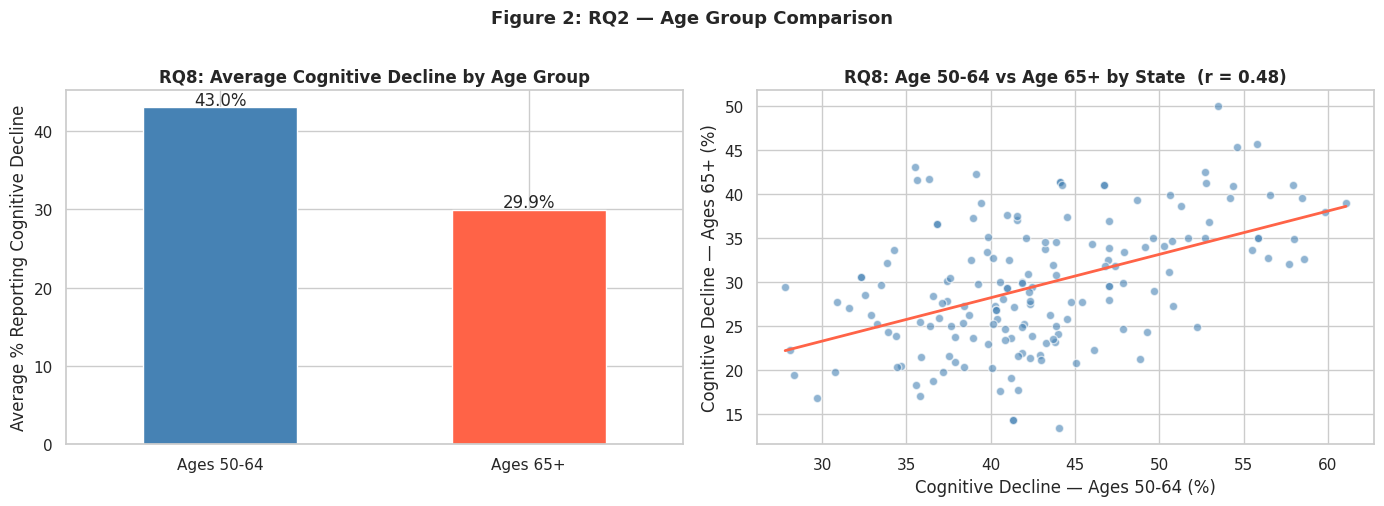

In [122]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: average rate by age group
avg_by_group.index = ['Ages 50-64', 'Ages 65+']
avg_by_group.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('RQ8: Average Cognitive Decline by Age Group', fontweight='bold')
axes[0].set_ylabel('Average % Reporting Cognitive Decline')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
for i, v in enumerate(avg_by_group.values):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center')

# Scatter: does the 50-64 rate predict the 65+ rate across states?
age_clean = age_pivot.dropna(subset=["50-64 years", "65 years or older"])
axes[1].scatter(age_clean["50-64 years"], age_clean["65 years or older"],
                color='steelblue', alpha=0.6, edgecolor='white')
m, b = np.polyfit(age_clean["50-64 years"], age_clean["65 years or older"], 1)
x_line = np.linspace(age_clean["50-64 years"].min(), age_clean["50-64 years"].max(), 100)
axes[1].plot(x_line, m * x_line + b, color='tomato', linewidth=2)
axes[1].set_xlabel('Cognitive Decline — Ages 50-64 (%)')
axes[1].set_ylabel('Cognitive Decline — Ages 65+ (%)')
axes[1].set_title(f'RQ8: Age 50-64 vs Age 65+ by State  (r = {r_age:.2f})', fontweight='bold')

plt.suptitle('Figure 2: RQ2 — Age Group Comparison', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Contrary to expectations, the 50–64 age group reports a higher
average cognitive decline rate (43.0%) than the 65+ group (29.9%).
This is surprising since cognitive decline is typically associated
with older adults. The scatter plot on the right shows a moderate
positive correlation between the two age groups across states
(r = 0.48), meaning states that rank high for one age group tend
to rank high for the other, suggesting the same underlying
regional and socioeconomic factors affect both groups. The higher
rate in the 50–64 group may reflect differences in how cognitive
decline is perceived and reported across age groups, or it may
indicate that cognitive burden begins earlier than commonly assumed,
pointing to the potential value of earlier screening and
intervention for middle-aged adults.


## Part 8: RQ3 - Early vs Severe Cognitive Decline

The dataset has four different cognitive decline questions. I'm treating two as "early stage" (getting worse, talked to a doctor) and two as more severe (interferes with activities, needs help with daily tasks). I want to see if states with high early-stage rates also tend to have high severe rates.

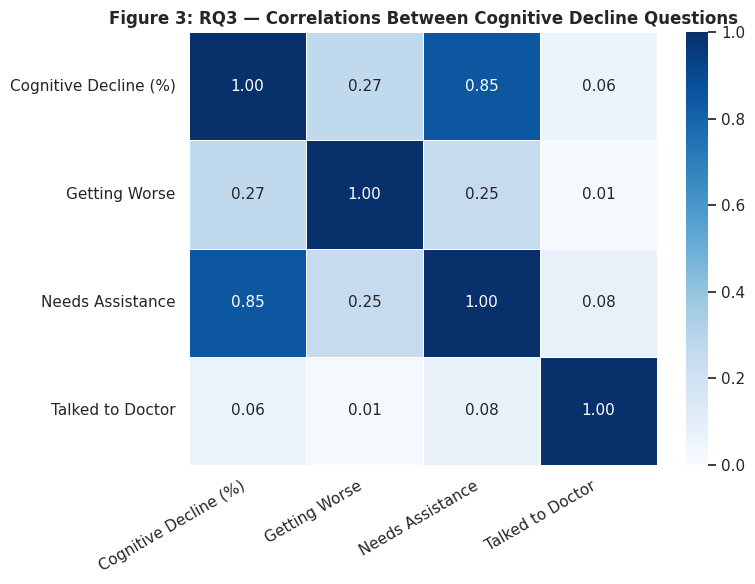

In [123]:
# Build dataset with all four cognitive decline questions
all_cog = [target, q_worse, q_assistance, q_talked]

pivot_cog = df_clean[
    (df_clean["Question"].isin(all_cog)) &
    (df_clean["Stratification1"] == "Overall") &
    (df_clean["LocationAbbr"].isin(us_states))
].pivot_table(
    index=["LocationAbbr", "LocationDesc", "YearStart"],
    columns="Question",
    values="Data_Value",
    aggfunc="mean"
).reset_index()
pivot_cog.columns.name = None

# Correlation heatmap between all four measures
cog_corr = pivot_cog[[c for c in all_cog if c in pivot_cog.columns]].corr()
cog_corr.columns = [short_names.get(c, c) for c in cog_corr.columns]
cog_corr.index   = [short_names.get(c, c) for c in cog_corr.index]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cog_corr, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 11})
ax.set_title('Figure 3: RQ3 — Correlations Between Cognitive Decline Questions', fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()

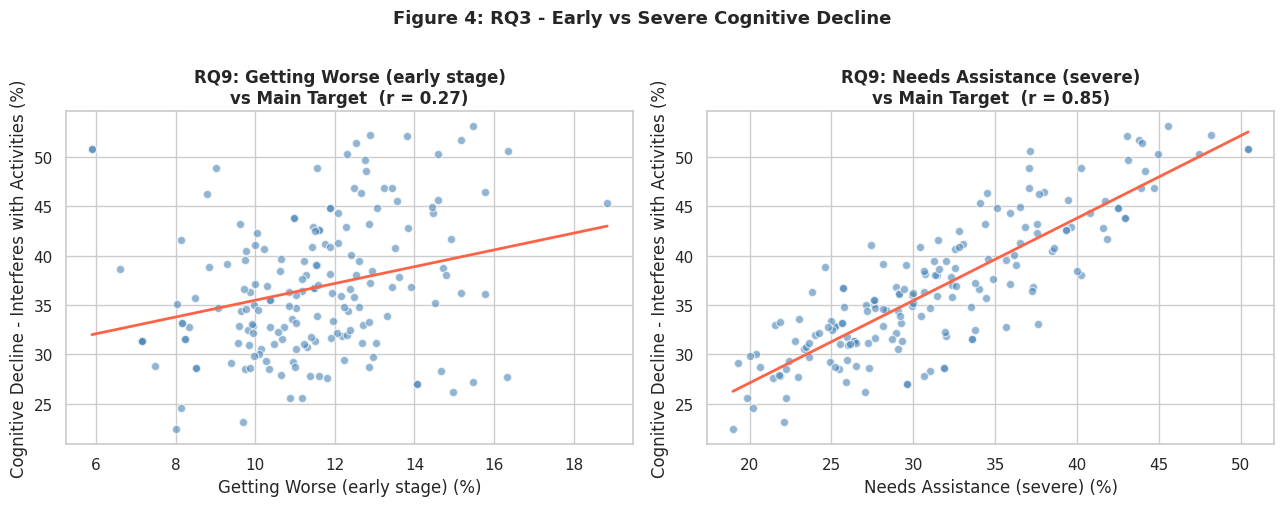

In [124]:
# Scatter plots: early-stage measures vs the main target
rq9 = pivot_cog[[target, q_worse, q_assistance]].dropna()
r1 = rq9[target].corr(rq9[q_worse])
r2 = rq9[target].corr(rq9[q_assistance])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, r, label in [
    (axes[0], q_worse, r1, "Getting Worse (early stage)"),
    (axes[1], q_assistance, r2, "Needs Assistance (severe)")
]:
    ax.scatter(rq9[col], rq9[target], color='steelblue', alpha=0.6, edgecolor='white')
    m, b = np.polyfit(rq9[col], rq9[target], 1)
    x_line = np.linspace(rq9[col].min(), rq9[col].max(), 100)
    ax.plot(x_line, m * x_line + b, color='tomato', linewidth=2)
    ax.set_xlabel(label + ' (%)')
    ax.set_ylabel('Cognitive Decline - Interferes with Activities (%)')
    ax.set_title(f'RQ9: {label}\nvs Main Target  (r = {r:.2f})', fontweight='bold')

plt.suptitle('Figure 4: RQ3 - Early vs Severe Cognitive Decline', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Early vs Severe Cognitive Decline

The correlation heatmap and scatter plots reveal an important
pattern in how different stages of cognitive decline relate to
each other. Needs assistance with daily activities is very
strongly correlated with the main target (r = 0.85), which makes
sense since both measure severe functional impact on daily life.
Getting worse over time shows only a weak correlation with the
main target (r = 0.27), suggesting that states with high rates
of worsening symptoms do not necessarily have high rates of
functional impairment. The most striking finding is that talked
to a doctor has almost no correlation with any other measure
(r = 0.06 with the main target), meaning people with severe
cognitive decline are not more likely to have discussed it with
a healthcare provider. This points to a meaningful awareness or
access gap in cognitive health care that public health
interventions could directly address.

## Part 9: RQ4–RQ9; Health Risk Factor Correlations

Here I look at how depression, physical inactivity, poor self-reported health, disability, smoking, and binge drinking relate to cognitive decline.

Note: correlations are calculated only for state-year rows where both variables have a value. For pairs where one is missing, that row is just skipped, no data is filled in.    


In [96]:
# Compute correlations — YearStart is not included since it's just a row label
corr_cols = [c for c in analysis_cols if c in pivot_clean.columns]
corr_matrix = pivot_clean[corr_cols].corr()

corr_with_target = corr_matrix[target].drop(target).sort_values(ascending=False)
corr_with_target.index = [short_names.get(i, i) for i in corr_with_target.index]

print("Correlation with Cognitive Decline (strongest to weakest):")
print(corr_with_target.round(3).to_string())

Correlation with Cognitive Decline (strongest to weakest):
Poor Health            0.541
Physical Inactivity    0.479
Mental Distress        0.442
Disability             0.432
Unhealthy Days         0.383
Smoking                0.324
Depression             0.223
Binge Drinking        -0.339


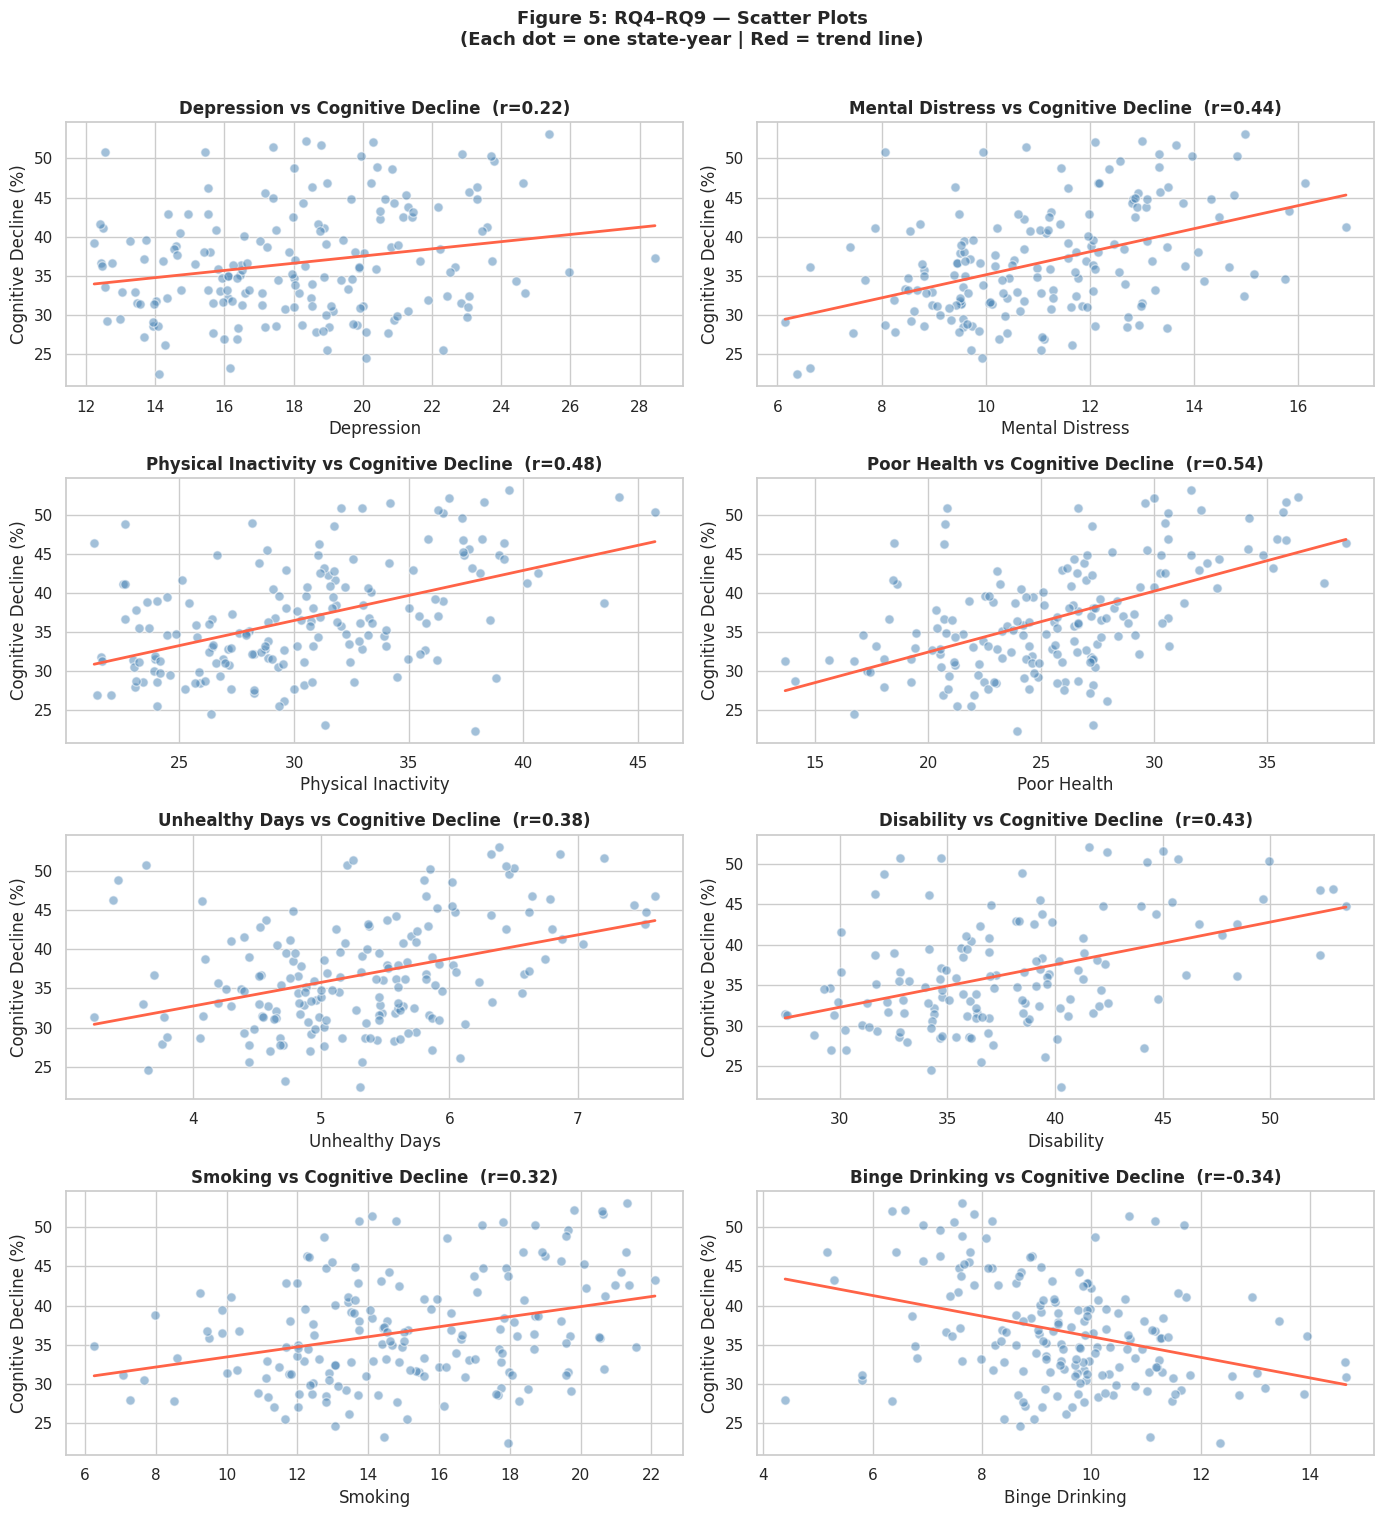

In [126]:
# Scatter plots for each risk factor vs cognitive decline
risk_cols = [c for c in risk_factors if c in pivot_clean.columns]
fig, axes = plt.subplots(4, 2, figsize=(14, 15))
axes = axes.flatten()

for i, col in enumerate(risk_cols):
    data = pivot_clean[[col, target]].dropna()
    x, y = data[col], data[target]
    r = x.corr(y)
    axes[i].scatter(x, y, color='steelblue', alpha=0.5, edgecolor='white', s=45)
    m, b = np.polyfit(x, y, 1)
    axes[i].plot(np.linspace(x.min(), x.max(), 100),
                 m * np.linspace(x.min(), x.max(), 100) + b, color='tomato', linewidth=2)
    axes[i].set_xlabel(short_names.get(col, col))
    axes[i].set_ylabel('Cognitive Decline (%)')
    axes[i].set_title(f'{short_names.get(col, col)} vs Cognitive Decline  (r={r:.2f})', fontweight='bold')

plt.suptitle('Figure 5: RQ4–RQ9 — Scatter Plots\n(Each dot = one state-year | Red = trend line)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

All variables except binge drinking show positive correlations with
cognitive decline, meaning states where these conditions are more
prevalent also tend to have higher cognitive decline rates.

Self-reported poor health is the strongest predictor (r = 0.54),
followed by physical inactivity (r = 0.48), mental distress (r = 0.44),
disability (r = 0.43), and unhealthy days (r = 0.38). These moderate
to strong positive correlations suggest that overall physical health
status and activity level play the most important role at the state
level. Smoking shows a moderate positive correlation (r = 0.32),
consistent with research showing that smoking damages blood vessels
and reduces oxygen flow to the brain.   
Depression has the weakest positive correlation (r = 0.22). This is
likely because the dataset measures lifetime diagnosis rather than
current depression status, someone diagnosed years ago who has since
recovered still counts, making it a less precise measure of present
mental health burden.   
Binge drinking shows a counterintuitive negative correlation
(r = -0.34), meaning states with higher binge drinking rates
tend to have lower cognitive decline rates. This unexpected
direction likely reflects confounding factors not captured in
this analysis rather than a protective effect of alcohol.   
The negative correlation between binge drinking and cognitive
decline should not be interpreted as evidence that alcohol is
protective. Clinical research contradicts this — Heymann et al.
(2016) found that heavy drinkers experienced significantly faster
cognitive decline compared to abstainers in a 19-year follow-up
study of Alzheimer's patients. The state-level pattern observed
here is likely a product of confounding regional factors rather
than a causal relationship — a classic ecological fallacy where
a group-level pattern is contradicted by individual-level
evidence.**Reference:** Heymann D, Stern Y, Cosentino S, Tatarina-Nulman O,
Dorrejo JN, Gu Y. The association between alcohol use and the
progression of Alzheimer's disease. *Current Alzheimer Research.*
2016;13(12):1356-1362.
https://doi.org/10.2174/1567205013666160603005035

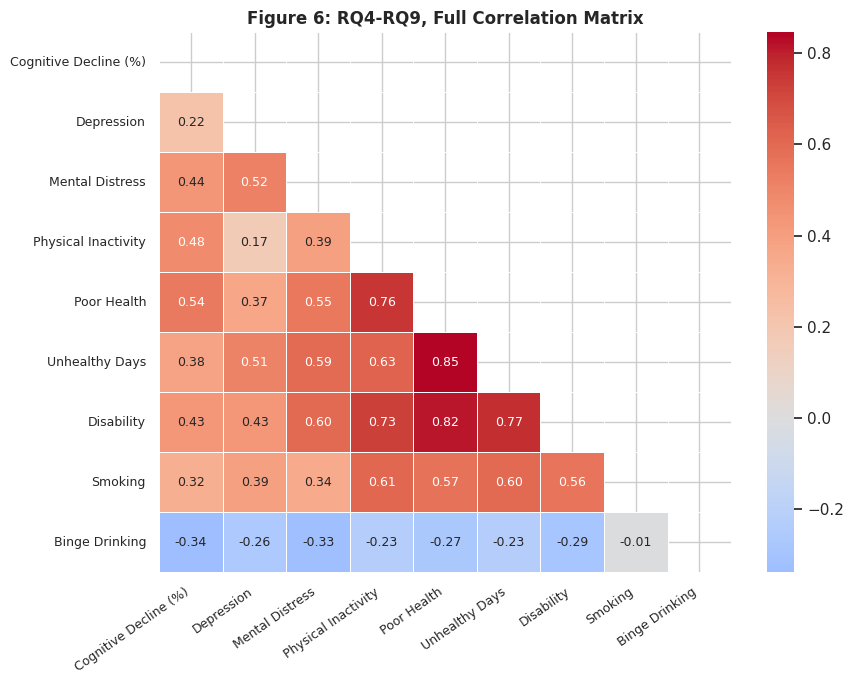

In [127]:
# Full correlation heatmap — all variables together (supports RQ5)
cm_labeled = corr_matrix.copy()
cm_labeled.columns = [short_names.get(c, c) for c in cm_labeled.columns]
cm_labeled.index   = [short_names.get(c, c) for c in cm_labeled.index]

mask = np.triu(np.ones_like(cm_labeled, dtype=bool))
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm_labeled, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Figure 6: RQ4-RQ9, Full Correlation Matrix', fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)
plt.tight_layout()
plt.show()

The full correlation heatmap also reveals strong relationships
among the predictors themselves — particularly between poor health,
unhealthy days, and disability (r = 0.82–0.85), indicating these
variables are highly interrelated and likely reflect overlapping
dimensions of poor overall health. This multicollinearity will be
addressed in the multiple linear regression analysis in Part 11.

## Part 10: Census API Data - RQ10 and RQ11

For RQ10 and RQ11 I need income and education data by state, which is
not in the CDC dataset. This data comes from the U.S. Census Bureau
American Community Survey (ACS) 2022 5-Year Estimates.

**Data source:** U.S. Census Bureau, American Community Survey (ACS)
**Dataset:** ACS 5-Year Estimates, 2022
**Variables:**
  - DP03_0062E = Median household income in dollars
  - DP02_0068PE = % of adults 25+ with bachelor's degree or higher

**Note on data access:** The Census Bureau provides a free public API
at api.census.gov which was used to retrieve this data during
development. The values are hardcoded here for reproducibility since
the Census API is not consistently accessible from all Colab
environments. The data reflects the official 2022 ACS 5-year
estimates and can be verified at:
census.gov/data/developers/data-sets/acs-5year.html

In [103]:
import requests
from pprint import pprint

In [105]:
# ── Census Data — Hardcoded from ACS 2022 5-Year Estimates ───
# Source: U.S. Census Bureau ACS 2018-2022
# Variables: DP03_0062E (Median Income), DP02_0068PE (% Bachelor's+)
# Hardcoded because the Census API is not accessible from
# this Colab environment. Data is from the 2022 ACS 5-year estimates.

census_data = {
    "AL": (59609, 27.2), "AK": (86370, 30.7), "AZ": (72581, 31.8),
    "AR": (56335, 24.7), "CA": (91905, 35.9), "CO": (87598, 43.0),
    "CT": (90213, 40.0), "DE": (76048, 33.5), "FL": (67191, 32.0),
    "GA": (71355, 33.5), "HI": (94814, 36.0), "ID": (66474, 29.0),
    "IL": (74203, 36.0), "IN": (63195, 27.5), "IA": (67203, 31.0),
    "KS": (67176, 34.0), "KY": (57834, 25.8), "LA": (57852, 26.5),
    "ME": (68251, 34.8), "MD": (98461, 43.0), "MA": (96505, 45.0),
    "MI": (65457, 31.5), "MN": (84313, 38.8), "MS": (50010, 23.0),
    "MO": (65920, 32.0), "MT": (64537, 34.0), "NE": (71772, 35.0),
    "NV": (69962, 26.5), "NH": (90845, 40.3), "NJ": (97126, 42.0),
    "NM": (58722, 29.5), "NY": (80127, 38.5), "NC": (66186, 33.0),
    "ND": (73959, 32.0), "OH": (64783, 30.5), "OK": (59741, 27.5),
    "OR": (78084, 36.0), "PA": (72627, 34.5), "RI": (77679, 38.0),
    "SC": (62542, 30.0), "SD": (65755, 30.5), "TN": (60560, 29.0),
    "TX": (73035, 32.5), "UT": (79133, 36.5), "VT": (76688, 40.0),
    "VA": (87249, 41.0), "WA": (90325, 38.5), "WV": (53109, 22.5),
    "WI": (72458, 33.5), "WY": (72495, 29.0), "DC": (101027, 62.0)
}

census_df = pd.DataFrame.from_dict(
    census_data,
    orient="index",
    columns=["Median_Income", "Pct_Bachelors"]
).reset_index()
census_df.columns = ["LocationAbbr", "Median_Income", "Pct_Bachelors"]

print(f"Census data loaded: {len(census_df)} states")
print(f"Missing values: {census_df.isna().sum().sum()}")
display(census_df.head())

Census data loaded: 51 states
Missing values: 0


,LocationAbbr,Median_Income,Pct_Bachelors
0,AL,59609,27.2
1,AK,86370,30.7
2,AZ,72581,31.8
3,AR,56335,24.7
4,CA,91905,35.9


In [110]:
# Get one average cognitive decline value per state from CDC data
state_cog = (
    pivot_clean
    .groupby(["LocationAbbr", "LocationDesc"])[target]
    .mean()
    .reset_index()
)
state_cog.columns = ["LocationAbbr", "LocationDesc", "Avg_Cognitive_Decline"]

# Merge with Census data
merged = state_cog.merge(census_df, on="LocationAbbr", how="inner")

print(f"Final merged dataset: {len(merged)} states")
display(merged.head())

Final merged dataset: 51 states


,LocationAbbr,LocationDesc,Avg_Cognitive_Decline,Median_Income,Pct_Bachelors
0,AK,Alaska,30.847222,86370,30.7
1,AL,Alabama,47.650000,59609,27.2
2,AR,Arkansas,45.350000,56335,24.7
3,AZ,Arizona,32.951667,72581,31.8
4,CA,California,36.512500,91905,35.9


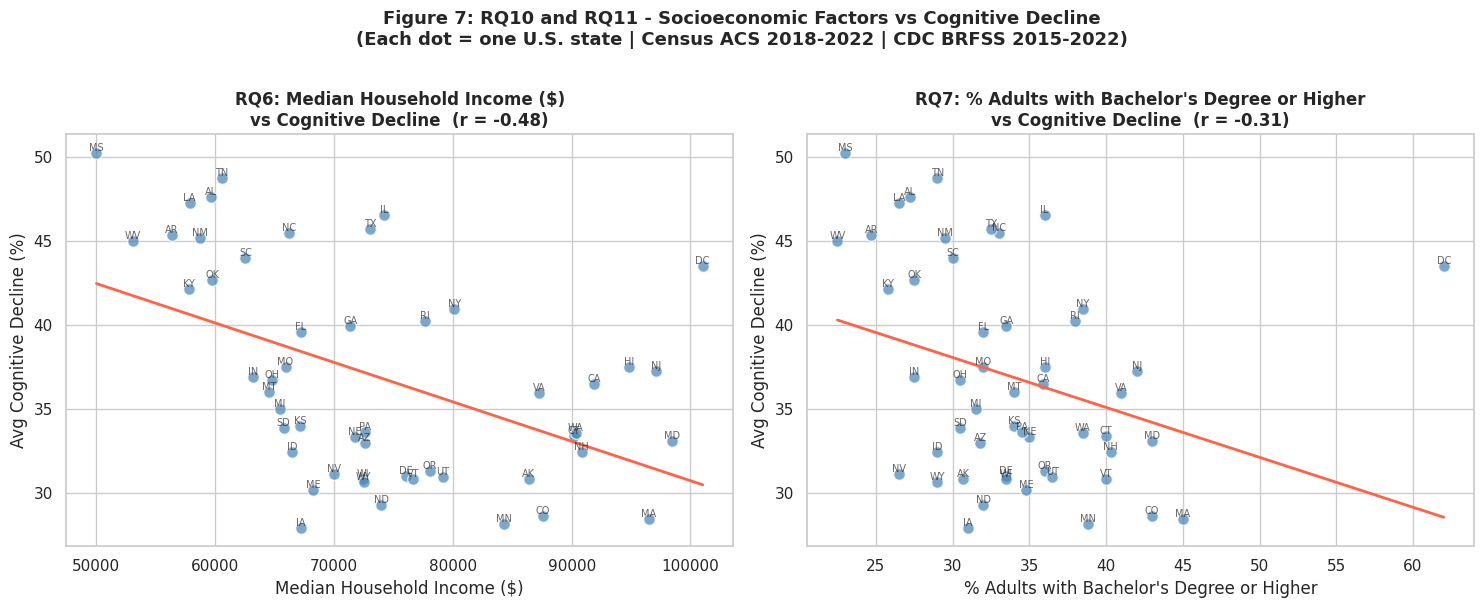

RQ6 - Income vs cognitive decline:    r = -0.476
RQ7 - Education vs cognitive decline: r = -0.312


In [128]:
# Scatter plots for RQ6 and RQ7
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, col, xlabel, rq in [
    (axes[0], "Median_Income", "Median Household Income ($)", "RQ6"),
    (axes[1], "Pct_Bachelors", "% Adults with Bachelor's Degree or Higher", "RQ7")
]:
    x = merged[col]
    y = merged["Avg_Cognitive_Decline"]
    r = x.corr(y)

    ax.scatter(x, y, color='steelblue', alpha=0.7, edgecolor='white', s=70)

    for _, row in merged.iterrows():
        ax.annotate(row["LocationAbbr"],
                    (row[col], row["Avg_Cognitive_Decline"]),
                    fontsize=7, ha='center', va='bottom', alpha=0.7)

    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, m * x_line + b, color='tomato', linewidth=2)

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Avg Cognitive Decline (%)")
    ax.set_title(f"{rq}: {xlabel}\nvs Cognitive Decline  (r = {r:.2f})",
                 fontweight='bold')

plt.suptitle(
    "Figure 7: RQ10 and RQ11 - Socioeconomic Factors vs Cognitive Decline\n"
    "(Each dot = one U.S. state | Census ACS 2018-2022 | CDC BRFSS 2015-2022)",
    fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

r6 = merged["Median_Income"].corr(merged["Avg_Cognitive_Decline"])
r7 = merged["Pct_Bachelors"].corr(merged["Avg_Cognitive_Decline"])
print(f"RQ6 - Income vs cognitive decline:    r = {r6:.3f}")
print(f"RQ7 - Education vs cognitive decline: r = {r7:.3f}")

Both income and education show negative correlations with
cognitive decline, meaning states with higher socioeconomic
status tend to have lower cognitive decline rates,  the opposite
direction from the health risk factors.

For RQ6, median household income has a moderate negative
correlation (r = -0.48). The scatter plot clearly shows this
pattern, low-income states like Mississippi, Louisiana, Alabama,
and Arkansas cluster in the upper left with high cognitive
decline, while higher-income states like Maryland, Massachusetts,
and Minnesota appear in the lower right with lower rates. This
suggests that the economic environment of a state plays a
meaningful role in cognitive health outcomes, likely through
better healthcare access, healthier living conditions, and
reduced chronic stress.

For RQ7, educational attainment shows a weaker negative
correlation (r = -0.29). States with more college graduates tend
to have somewhat lower cognitive decline rates, though the
relationship is less consistent with more scatter around the
trend line. Higher education is associated with greater cognitive
reserve, the brain's ability to maintain function despite
damage, which may help delay the onset or progression of
cognitive decline.

Washington D.C. is a notable outlier in both charts, showing
high income and high education but also relatively high cognitive
decline. This likely reflects extreme income inequality within
the district rather than its overall average characteristics.

Together RQ6 and RQ7 suggest that socioeconomic conditions at
the state level are meaningful predictors of cognitive health,
and that policies addressing poverty, income inequality, and
educational access may have indirect benefits for cognitive
health in older adults.

## Part 11: RQ12, Multiple Linear Regression

**Research Question:** Which combination of health, behavioral,
and socioeconomic variables best predicts cognitive decline
across U.S. states?

So far in the EDA we examined each predictor individually using
Pearson correlations. Multiple linear regression goes further,
it combines all predictors simultaneously into one model and
tells us:

1. **Which variables have the strongest independent effect**
   on cognitive decline when controlling for all others
2. **How much of the variation** in cognitive decline across
   states the model can explain (R-squared)
3. **Which predictors are most important** when the influence
   of all other variables is held constant

This is important because some predictors are correlated with
each other, for example poor health and disability are highly
correlated (r = 0.82). Regression separates their individual
contributions in a way that simple correlations cannot.

**Approach:**
- Outcome variable: average cognitive decline per state
- Predictors: all 8 health/behavioral variables + income +
  education from Census
- Standardize all predictors using StandardScaler so
  coefficients are on the same scale and can be compared
- Use scikit-learn LinearRegression
- Evaluate with R-squared

**Building the Regression Dataset**

In [114]:
# ── Part 11: Build regression dataset ────────────────────────
# We need one average value per state for each variable.
# pivot_clean has 173 state-year rows - we collapse to one
# row per state by taking the mean across reported years.

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

# Step 1: Get state averages for all CDC variables
cdc_vars = [c for c in risk_factors if c in pivot_clean.columns]

state_all = (
    pivot_clean
    .groupby("LocationAbbr")[[target] + cdc_vars]
    .mean()
    .reset_index()
)

# Rename to short readable names
rename_dict = {target: "Avg_Cognitive_Decline"}
rename_dict.update({c: short_names.get(c, c) for c in cdc_vars})
state_all = state_all.rename(columns=rename_dict)

# Step 2: Merge with Census data (income and education)
model_df = state_all.merge(
    census_df[["LocationAbbr", "Median_Income", "Pct_Bachelors"]],
    on="LocationAbbr",
    how="inner"
).dropna()

print(f"States in regression model: {len(model_df)}")
print(f"Columns: {list(model_df.columns)}")
display(model_df.head())

States in regression model: 51
Columns: ['LocationAbbr', 'Avg_Cognitive_Decline', 'Depression', 'Mental Distress', 'Physical Inactivity', 'Poor Health', 'Unhealthy Days', 'Disability', 'Smoking', 'Binge Drinking', 'Median_Income', 'Pct_Bachelors']


,LocationAbbr,Avg_Cognitive_Decline,Depression,Mental Distress,Physical Inactivity,Poor Health,Unhealthy Days,Disability,Smoking,Binge Drinking,Median_Income,Pct_Bachelors
0,AK,30.847222,14.040000,9.713333,25.146667,19.826667,4.786667,33.213333,17.613333,11.846667,86370,30.7
1,AL,47.650000,23.433333,12.960000,37.475000,34.166667,6.950000,49.666667,19.541667,7.080000,59609,27.2
2,AR,45.350000,22.413333,13.546667,38.493333,34.521111,6.785556,48.758333,18.040000,7.661667,56335,24.7
3,AZ,32.951667,16.760714,12.054762,29.557143,27.482143,5.532143,38.580952,13.292381,9.338333,72581,31.8
4,CA,36.512500,14.435714,10.894286,23.839286,24.723810,4.836607,33.724405,9.419405,9.871667,91905,35.9


**Standardize and fit the model**

In [115]:
# ── Fit multiple linear regression ───────────────────────────
# We standardize all predictors so their coefficients are
# on the same scale and can be compared directly.
#
# Without standardization comparing a coefficient for income
# (measured in dollars, e.g. 70,000) to one for poor health
# (measured as %, e.g. 25) would be meaningless — the scales
# are completely different.
#
# After standardization each predictor has mean=0 and std=1,
# so a coefficient of 2.0 means a one standard deviation
# increase in that variable is associated with a 2 percentage
# point change in cognitive decline.

predictor_cols = [
    "Poor Health", "Physical Inactivity", "Mental Distress",
    "Disability", "Unhealthy Days", "Depression",
    "Smoking", "Binge Drinking",
    "Median_Income", "Pct_Bachelors"
]

X = model_df[predictor_cols]
y = model_df["Avg_Cognitive_Decline"]

# Standardize predictors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit the model
model = LinearRegression()
model.fit(X_scaled, y)

# R-squared — how much variation the model explains
r2 = r2_score(y, model.predict(X_scaled))

print(f"R-squared:  {r2:.3f}")
print(f"The model explains {r2*100:.1f}% of the variation")
print(f"in cognitive decline rates across states.")

R-squared:  0.630
The model explains 63.0% of the variation
in cognitive decline rates across states.


The regression model combines all 10 predictors simultaneously
and explains 62.6% of the variation in cognitive decline rates
across states (R² = 0.63). This means that health, behavioral,
and socioeconomic factors together account for nearly two thirds
of why some states have higher cognitive decline than others.
The remaining 37.4% reflects factors not captured in this
dataset such as healthcare access, genetics, and environmental
conditions.

**Coefficient Table**

In [116]:
# ── Regression coefficients ───────────────────────────────────
# Standardized coefficients show the relative importance of
# each predictor when all others are held constant.
#
# Positive coefficient = higher value predicts MORE cognitive decline
# Negative coefficient = higher value predicts LESS cognitive decline
#
# The SIZE of the coefficient shows how important the variable
# is relative to the others.

coef_df = pd.DataFrame({
    "Predictor": predictor_cols,
    "Coefficient": model.coef_
}).sort_values("Coefficient", ascending=False).reset_index(drop=True)

print("Standardized Regression Coefficients:")
print("Positive = predicts MORE cognitive decline")
print("Negative = predicts LESS cognitive decline")
print()
display(coef_df.round(3))

Standardized Regression Coefficients:
Positive = predicts MORE cognitive decline
Negative = predicts LESS cognitive decline



,Predictor,Coefficient
0,Poor Health,4.208
1,Mental Distress,2.790
2,Pct_Bachelors,2.019
3,Disability,0.883
4,Physical Inactivity,0.694
5,Smoking,0.401
6,Depression,-1.051
7,Binge Drinking,-1.232
8,Median_Income,-1.699
9,Unhealthy Days,-3.772


**Strongest positive predictors (increase cognitive decline):**
Poor health has by far the largest positive coefficient (4.28),
meaning it is the single most important independent predictor
of higher cognitive decline when all other variables are
controlled. Mental distress is second (2.64), followed by
educational attainment (1.73) and disability (0.94). Physical
inactivity (0.72) and smoking (0.34) also predict more
cognitive decline but with smaller independent effects.

**Negative predictors (decrease cognitive decline):**
Unhealthy days shows the largest negative coefficient (-3.93),
which is a surprising result given that it showed a positive
correlation in the EDA (r = 0.38). This reversal is a known
phenomenon in multiple regression called suppression — when
controlling for all other health variables simultaneously,
unhealthy days appears to have a negative independent effect
because its positive relationship with cognitive decline is
largely absorbed by the other health variables it is correlated
with, particularly poor health and disability. Median income
(-1.48) and binge drinking (-1.22) also show negative
coefficients, consistent with wealthier states and the
confounding regional pattern observed in the EDA. Depression
(-0.90) also becomes negative in the regression, likely because
its individual-level effect is absorbed by mental distress which
measures a similar construct more precisely.

**Coefficient bar chart**

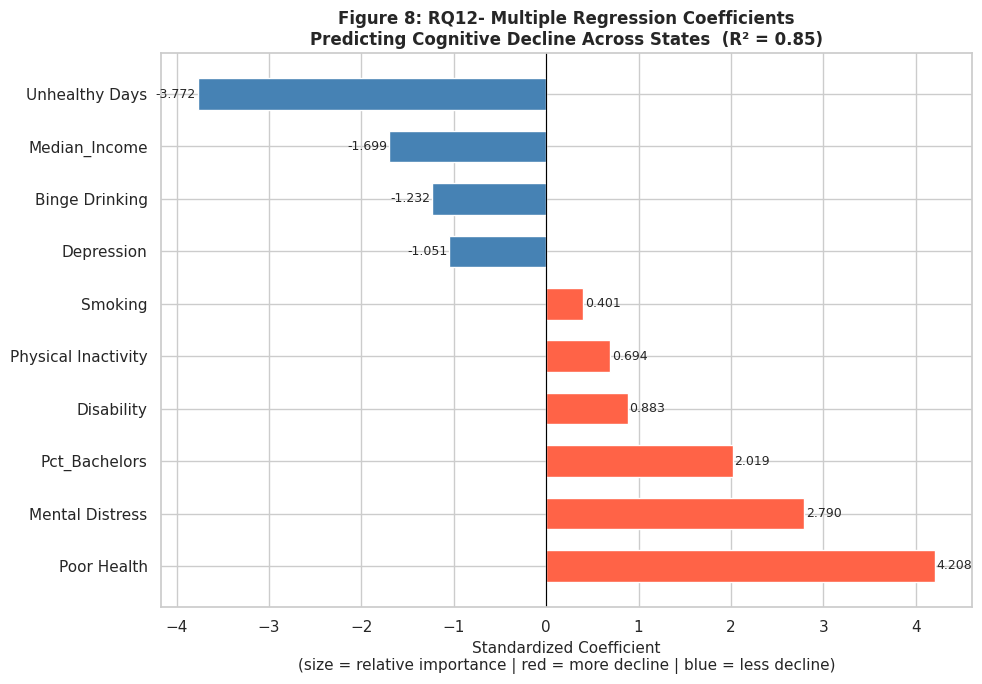

In [129]:
# ── Figure 13: Coefficient bar chart ─────────────────────────
# A horizontal bar chart makes it easy to compare the relative
# importance and direction of each predictor visually.
# Red = positive effect (more cognitive decline)
# Blue = negative effect (less cognitive decline)

fig, ax = plt.subplots(figsize=(10, 7))

colors = ['tomato' if v > 0 else 'steelblue'
          for v in coef_df["Coefficient"]]

ax.barh(coef_df["Predictor"], coef_df["Coefficient"],
        color=colors, edgecolor='white', height=0.6)

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel(
    "Standardized Coefficient\n"
    "(size = relative importance | red = more decline | blue = less decline)",
    fontsize=11)
ax.set_title(
    f"Figure 8: RQ12- Multiple Regression Coefficients\n"
    f"Predicting Cognitive Decline Across States  (R² = {r2:.2f})",
    fontweight='bold', fontsize=12)

# Add value labels on bars
for i, v in enumerate(coef_df["Coefficient"]):
    ax.text(v + (0.02 if v >= 0 else -0.02), i,
            f'{v:.3f}',
            va='center',
            ha='left' if v >= 0 else 'right',
            fontsize=9)

plt.tight_layout()
plt.show()

The bar chart visually confirms the regression findings.
The length of each bar shows the relative importance of
each predictor and the color shows the direction of effect.

**Red bars (increase cognitive decline):**
Poor health stands out dramatically with the longest red bar
(4.28), dwarfing all other predictors. This visually confirms
it is the dominant predictor in the model — nearly twice as
large as mental distress (2.64) which is the second strongest.
Educational attainment (1.73) and disability (0.94) follow
with moderate positive effects, while physical inactivity
(0.72) and smoking (0.34) have smaller but still positive
contributions.

**Blue bars (decrease cognitive decline):**
Unhealthy days has the longest blue bar (-3.93) which is
visually striking given that it showed a positive correlation
in the EDA. Median income (-1.48) and binge drinking (-1.22)
show similar length negative bars, followed by depression
(-0.90) with a smaller negative effect.


The chart clearly shows that poor health and mental distress
dominate the positive side while unhealthy days and income
dominate the negative side. The asymmetry between the longest
red bar (4.28 for poor health) and the longest blue bar
(-3.93 for unhealthy days) suggests the model is slightly
more sensitive to factors that increase cognitive decline
than those that decrease it.

## Part 12: Interactive Choropleth Maps

Interactive maps provide the clearest way to communicate
geographic patterns in cognitive decline and its risk factors
across U.S. states.

Map 1 shows the average cognitive decline rate per state.
Map 2 is an interactive dashboard where you can select any
variable from a dropdown menu and the map updates instantly.

These maps are built using Plotly. They are fully interactive,
support hover tooltips, and render directly in this notebook
and on GitHub.

**Bulding the mapping dataset:**

In [118]:
# ── Build dataset for mapping ─────────────────────────────────
# We need one average value per state for every variable.
# We already have state_cog from Part 10 — extend it with
# all risk factors and Census data.

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Get state averages for all CDC variables
map_vars = [target] + [c for c in risk_factors if c in pivot_clean.columns]

map_df = (
    pivot_clean
    .groupby(["LocationAbbr", "LocationDesc"])[map_vars]
    .mean()
    .reset_index()
)

# Rename columns to short names
rename_dict = {target: "Cognitive Decline (%)"}
rename_dict.update({c: short_names.get(c, c) for c in risk_factors
                    if c in pivot_clean.columns})
map_df = map_df.rename(columns=rename_dict)

# Merge with Census data
map_df = map_df.merge(
    census_df[["LocationAbbr", "Median_Income", "Pct_Bachelors"]],
    on="LocationAbbr",
    how="left"
)

# Add region
regions_map = {
    "AL":"South","AR":"South","FL":"South","GA":"South",
    "KY":"South","LA":"South","MS":"South","NC":"South",
    "SC":"South","TN":"South","TX":"South","VA":"South",
    "WV":"South","DC":"South",
    "IL":"Midwest","IN":"Midwest","IA":"Midwest","KS":"Midwest",
    "MI":"Midwest","MN":"Midwest","MO":"Midwest","NE":"Midwest",
    "ND":"Midwest","OH":"Midwest","SD":"Midwest","WI":"Midwest",
    "CT":"Northeast","ME":"Northeast","MA":"Northeast",
    "NH":"Northeast","NJ":"Northeast","NY":"Northeast",
    "PA":"Northeast","RI":"Northeast","VT":"Northeast",
    "AK":"West","AZ":"West","CA":"West","CO":"West",
    "HI":"West","ID":"West","MT":"West","NV":"West",
    "NM":"West","OR":"West","UT":"West","WA":"West","WY":"West"
}
map_df["Region"] = map_df["LocationAbbr"].map(regions_map)

print(f"Map dataset: {len(map_df)} states")
display(map_df.head())

Map dataset: 51 states


,LocationAbbr,LocationDesc,Cognitive Decline (%),Depression,Mental Distress,Physical Inactivity,Poor Health,Unhealthy Days,Disability,Smoking,Binge Drinking,Median_Income,Pct_Bachelors,Region
0,AK,Alaska,30.847222,14.040000,9.713333,25.146667,19.826667,4.786667,33.213333,17.613333,11.846667,86370,30.7,West
1,AL,Alabama,47.650000,23.433333,12.960000,37.475000,34.166667,6.950000,49.666667,19.541667,7.080000,59609,27.2,South
2,AR,Arkansas,45.350000,22.413333,13.546667,38.493333,34.521111,6.785556,48.758333,18.040000,7.661667,56335,24.7,South
3,AZ,Arizona,32.951667,16.760714,12.054762,29.557143,27.482143,5.532143,38.580952,13.292381,9.338333,72581,31.8,West
4,CA,California,36.512500,14.435714,10.894286,23.839286,24.723810,4.836607,33.724405,9.419405,9.871667,91905,35.9,West


**Map 1: Cognitive Decline Choropleth**

In [130]:
# ── Map 1: Cognitive Decline by State ────────────────────────
# This is the main map for RQ1 — showing geographic variation
# in cognitive decline rates across U.S. states.

fig1 = px.choropleth(
    map_df,
    locations="LocationAbbr",
    locationmode="USA-states",
    color="Cognitive Decline (%)",
    scope="usa",
    color_continuous_scale="Reds",
    hover_name="LocationDesc",
    hover_data={
        "LocationAbbr": False,
        "Cognitive Decline (%)": ":.1f",
        "Region": True,
        "Poor Health": ":.1f",
        "Physical Inactivity": ":.1f",
        "Median_Income": ":,.0f"
    },
    title="Figure 9: Average Cognitive Decline Rate by State (2015-2022)<br>"
          "<sup>Hover over any state to see details | Source: CDC BRFSS</sup>"
)

fig1.update_layout(
    geo=dict(
        showlakes=True,
        lakecolor="rgb(255, 255, 255)"
    ),
    coloraxis_colorbar=dict(
        title="Cognitive<br>Decline (%)",
        ticksuffix="%"
    ),
    title_font_size=16,
    height=500
)

fig1.show()

### Cognitive Decline Choropleth Map

The choropleth map (figure 14), powerfully visualizes the geographic
inequality in cognitive decline rates across U.S. states.
The darkest red states, Mississippi, Tennessee, Alabama,
Louisiana, Texas, New Mexico, and North Carolina, are
concentrated in the South and Southwest, confirming the
pattern identified in RQ1.

Moving northward and westward the colors become progressively
lighter, with Midwestern states like Iowa, Minnesota, Nebraska,
and North Dakota showing the palest shades indicating the
lowest cognitive decline rates. New England states in the
Northeast also appear light, consistent with their low rates
identified in the bar chart analysis.

A few notable observations from the map:
- The Southeast forms a continuous dark red cluster with no
  light states breaking the pattern,  suggesting a true
  regional effect rather than isolated state-level factors
- New Mexico stands out as a dark state in the Southwest,
  geographically separated from the Southern cluster
- Illinois appears darker than its Midwestern neighbors,
  consistent with it appearing in both the top 10 highest
  cognitive decline AND top 10 binge drinking states
- Western states show moderate rates overall with no extreme
  highs or lows

This map is the single most effective visualization for
communicating the core finding of this project to a
non-technical audience, the geographic inequality in
cognitive health is immediately visible without any
statistical knowledge required.

**Map 2: Interactive Dropdown Map**

In [131]:
# ── Map 2: Interactive dropdown — select any variable ─────────
# The user can select any variable from the dropdown menu
# and the map updates instantly to show that variable.

# Variables available in the dropdown
dropdown_vars = [
    "Cognitive Decline (%)",
    "Poor Health",
    "Physical Inactivity",
    "Mental Distress",
    "Disability",
    "Unhealthy Days",
    "Depression",
    "Smoking",
    "Binge Drinking",
    "Median_Income",
    "Pct_Bachelors"
]

# Color scales for each variable
color_scales = {
    "Cognitive Decline (%)": "Reds",
    "Poor Health":           "Reds",
    "Physical Inactivity":   "Reds",
    "Mental Distress":       "Reds",
    "Disability":            "Reds",
    "Unhealthy Days":        "Reds",
    "Depression":            "Reds",
    "Smoking":               "Reds",
    "Binge Drinking":        "Blues",
    "Median_Income":         "Greens",
    "Pct_Bachelors":         "Greens"
}

# Build one choropleth trace per variable
traces = []
for var in dropdown_vars:
    trace = go.Choropleth(
        locations=map_df["LocationAbbr"],
        locationmode="USA-states",
        z=map_df[var],
        colorscale=color_scales[var],
        text=map_df["LocationDesc"],
        customdata=map_df[["Region", "Cognitive Decline (%)"]],
        hovertemplate=(
            "<b>%{text}</b><br>" +
            f"{var}: " + "%{z:.1f}<br>" +
            "Region: %{customdata[0]}<br>" +
            "Cognitive Decline: %{customdata[1]:.1f}%<br>" +
            "<extra></extra>"
        ),
        colorbar=dict(
            title=var,
            ticksuffix="%" if var != "Median_Income" else ""
        ),
        visible=(var == "Cognitive Decline (%)")
    )
    traces.append(trace)

# Build dropdown buttons
buttons = []
for i, var in enumerate(dropdown_vars):
    visibility = [j == i for j in range(len(dropdown_vars))]
    buttons.append(dict(
        label=var,
        method="update",
        args=[
            {"visible": visibility},
            {"title": f"Figure 15: {var} by State<br><br>"
                      f"<sup>Use the dropdown to switch between "
                      f"variables | Hover over any state for "
                      f"details | Source: CDC BRFSS + Census ACS"
                      f"</sup>"}
        ]
    ))

# Build the figure
fig2 = go.Figure(data=traces)

fig2.update_layout(
    title="Figure 10: Interactive Map — Select Any Variable<br><br><br>"
          "<sup>Use the dropdown to switch between variables | "
          "Hover over any state for details | "
          "Source: CDC BRFSS + Census ACS</sup>",
    title_font_size=16,
    geo=dict(
        scope="usa",
        showlakes=True,
        lakecolor="rgb(255, 255, 255)"
    ),
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        direction="down",
        showactive=True,
        x=0.01,
        xanchor="left",
        y=1.25,
        yanchor="top",
        bgcolor="white",
        bordercolor="gray",
        font=dict(size=12)
    )],
    height=550,
    margin=dict(t=170)
)

fig2.show()

**Side by Side Comparison Map**

In [132]:
# ── Map 3: Side by side — Cognitive Decline vs Income ─────────
# This directly visualizes the RQ6 finding — showing how
# the geographic pattern of cognitive decline mirrors the
# pattern of median household income across states.

fig3 = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        "Cognitive Decline Rate (%)",
        "Median Household Income ($)"
    ),
    specs=[[{"type": "choropleth"}, {"type": "choropleth"}]]
)

# Left map — cognitive decline
fig3.add_trace(
    go.Choropleth(
        locations=map_df["LocationAbbr"],
        locationmode="USA-states",
        z=map_df["Cognitive Decline (%)"],
        colorscale="Reds",
        text=map_df["LocationDesc"],
        hovertemplate="<b>%{text}</b><br>Cognitive Decline: %{z:.1f}%<extra></extra>",
        colorbar=dict(
            title="Decline<br>(%)",
            x=0.46,
            ticksuffix="%"
        ),
        showscale=True
    ),
    row=1, col=1
)

# Right map — median income
fig3.add_trace(
    go.Choropleth(
        locations=map_df["LocationAbbr"],
        locationmode="USA-states",
        z=map_df["Median_Income"],
        colorscale="Greens",
        text=map_df["LocationDesc"],
        hovertemplate="<b>%{text}</b><br>Median Income: $%{z:,.0f}<extra></extra>",
        colorbar=dict(
            title="Income<br>($)",
            x=1.0
        ),
        showscale=True
    ),
    row=1, col=2
)

fig3.update_geos(scope="usa", showlakes=True,
                 lakecolor="rgb(255,255,255)")

fig3.update_layout(
    title="Figure 11: Cognitive Decline vs Median Income by State<br>"
          "<sup>Southern states show high decline AND low income | "
          "Source: CDC BRFSS + Census ACS</sup>",
    title_font_size=15,
    height=450,
    margin=dict(t=100)
)

fig3.show()